# Manipulations to multiscale simulations

ISF provides two strategies for identifying common mechanisms and quantifying the impact of individual mechanisms across multi-scale models. The first strategy is to manipulate specific properties of multi-scale models and investigate their effect on the neuronal responses, which will be covered in this tutorial. The second strategy is to reduce the multi-scale models to a minimal set of parameters that are sufficient to account for an in vivo observation, which will be covered in [the next tutorial](./4.2%20Reduced%20Models.ipynb).

The purpose of manipulating multi-scale simulations is to isolate the relevance of
individual mechanisms for the observed in vivo response. ISF can re-simulate existing 
multi-scale simulations with the exact same biophysical parameters, synapse locations 
and synapse activation times, while making any of the following targeted manipulations: 

- Scaling synaptic weights by distance, receptor type, presynaptic origin, or individually 
- Changing synaptic activation patterns by the same categories 
- Removing connectivity to presynaptic cells or populations 
- Changing biophysical parameters 
- Any combination of the above

ISF thereby enables the investigation of the exact effect of each component 
mechanism across a broad diversity of multi-scale simulations. The effect of these
manipulations, and to which degree these manipulations are robust under trial-to-trial, 
cell-to-cell and network variability provides mechanistic insight into the neuron and 
network properties and interactions underlying in vivo responses. The purpose of these 
manipulations is to generate concrete predictions about underlying mechanisms and 
thereby inform experiment design to verify these predictions empirically. 

## Broad receptive fields of L5PTs and input from L6cc

[Egger et al. (2020)](https://www.cell.com/neuron/fulltext/S0896-6273(19)30884-0) Showed how L5PT neurons are unable to respond to $2^{nd}$ surround whisker stimuli in the absence of input from Layer 6 cortico-cortical (L6CC) input.

We will repeat the manipulations performed in [Egger et al. (2020)](https://www.cell.com/neuron/fulltext/S0896-6273(19)30884-0) on a single neuron for a single trial, using the same parameter files we generated in [the previous tutorial](../3.%20multiscale%20models/3.1%20Multiscale%20modeling.ipynb).



Stimuli that are second surround to the $C2$ column are the rows $A$ and $E$, and arcs $4$ and $\gamma$ (here: $G$)

![Wistar rat whisker grid](../../../docs/_static/_images/whisker_grid.png)

## Simulating $2nd$ surround whisker responses

Let's consider a morphology that has been anchored to the center of the $C2$ column.
We have examples of such morphology in the example data folder. let's copy it over to a dedicated database:

In [ ]:
from pathlib import Path
tutorial_output_dir = f"{Path.home()}/isf_tutorial_output"  # <-- Change this to your desired output directory

In [2]:
import Interface as I
from getting_started import getting_started_dir

network_db = I.DataBase(tutorial_output_dir)['network_modeling']
db = I.DataBase(tutorial_output_dir).create_sub_db('multiscale_manipulations')

if not 'biophysical_constraints' in db.keys():
    cell_parameter_file = I.os.path.join(
        getting_started_dir, 
        'example_data',
        'biophysical_constraints', 
        '86_C2_center.param')
    I.shutil.copy(cell_parameter_file, db.create_managed_folder('biophysical_constraints'))
cell_parameter_file = db['biophysical_constraints'].join('86_C2_center.param')

[INFO] ISF: Current version: heads/docs+0.g1456ee0eb.dirty
[INFO] ISF: Current pid: 195809


--No graphics will be displayed.


[INFO] l5pt: Loaded mechanisms in NEURON namespace.
[ATTENTION] ISF: The source folder has uncommited changes!



[INFO] ISF: Loaded modules with __version__ attribute are:
IPython: 8.12.2, Interface: heads/docs+0.g1456ee0eb.dirty, PIL: 9.4.0, _brotli: 1.0.9, _csv: 1.0, _ctypes: 1.1.0, _curses: b'2.2', _decimal: 1.70, argparse: 1.1, backcall: 0.2.0, blosc: 1.11.1, bluepyopt: 1.9.126, brotli: 1.0.9, certifi: 2024.08.30, cffi: 1.17.0, charset_normalizer: 3.4.0, click: 7.1.2, cloudpickle: 3.1.0, colorama: 0.4.6, comm: 0.2.2, csv: 1.0, ctypes: 1.1.0, cycler: 0.12.1, cytoolz: 0.12.3, dash: 2.18.2, dask: 2.30.0, dateutil: 2.9.0, deap: 1.4, debugpy: 1.8.5, decimal: 1.70, decorator: 5.1.1, defusedxml: 0.7.1, distributed: 2.30.0, distutils: 3.8.15, entrypoints: 0.4, executing: 2.1.0, fasteners: 0.17.3, flask: 1.1.4, fsspec: 2024.10.0, future: 1.0.0, greenlet: 3.1.1, idna: 3.10, ipaddress: 1.0, ipykernel: 6.29.5, ipywidgets: 8.1.5, isf_pandas_msgpack: 0.4.0, itsdangerous: 1.1.0, jedi: 0.19.1, ji

In [64]:
second_surround_whisker = "C4"  # Some whisker that is second surround to C2

In [Tutorial 2.1](../2.%20network%20models/2.1%20Anatomical%20embedding.ipynb), we have already generated synapse locations for this $C2$-anchored neuron, which gave us [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files.
In [Tutorial 2.2](../2.%20network%20models/2.2%20Network%20activity.ipynb), we additionally generate activation patterns for these synapses that reflect a variety of stimuli, including those that come from $2nd$ surround whiskers. Let us take a look at those again:

In [ ]:
network_file = network_db['network_param'].join('{}_stim.param'.format(second_surround_whisker))
assert I.os.path.exists(network_file), "Please run tutorials 2.1 and 2.2 first"

In [65]:
delayeds = []

# Delete previous results, if they exist
if 'simrun' in db.keys(): 
    del db['simrun']
    
# Create new folder for results
db.create_managed_folder('simrun')

network_file = network_db['network_param'].join('{}_stim.param'.format(second_surround_whisker))
dir_prefix = db['simrun'].join('stim_{}'.format(second_surround_whisker))

nSweeps = 4 # number of consecutive simulations per process
nprocs = 4 # number of processes simulating that task in parallel    
tStop = 300 # stop the simulation at 300ms

d = I.simrun_run_new_simulations(
    cell_parameter_file, # defined in the above cell
    network_file, 
    dirPrefix = dir_prefix,
    nSweeps = nSweeps, 
    nprocs = nprocs, 
    tStop = tStop, 
    silent = False
)
delayeds.append(d)

[WARNING] isf_data_base: ISF has uncommitted changes - reproducing results may not be possible.


In [66]:
client = I.get_client()
client

Client Scheduler: tcp://10.100.2.201:38786 Dashboard: http://10.100.2.201:38787/status,Cluster Workers: 40 Cores: 40 Memory: 4.00 TB


In [ ]:
from dask.distributed import wait
futures = client.compute(delayeds)
wait(futures)

After the results are completed, they are saved here:

In [69]:
db['simrun'].join('stim_{}'.format(second_surround_whisker))

'/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/multiscale_manipulations/db/simrun/stim_C4'

Let's consolidate them again in a single database with efficient dataframes:

In [ ]:
I.db_init_simrun_general.init(
    db.create_sub_db("stim_{}".format(second_surround_whisker)),
    db['simrun'],
    client=client
)

## Analyzing the results

In [71]:
vt = db[f'stim_{second_surround_whisker}']['voltage_traces']
vt = client.compute(vt).result()

sa = db[f"stim_{second_surround_whisker}"]["synapse_activation"]

st = db[f"stim_{second_surround_whisker}"]['spike_times']

In [82]:
stim_onset = 245  # Check tutorial 2.2 or 3.1 for why this is 245 ms
converge_t = 150  # rough estimate of how long neuron models take to 

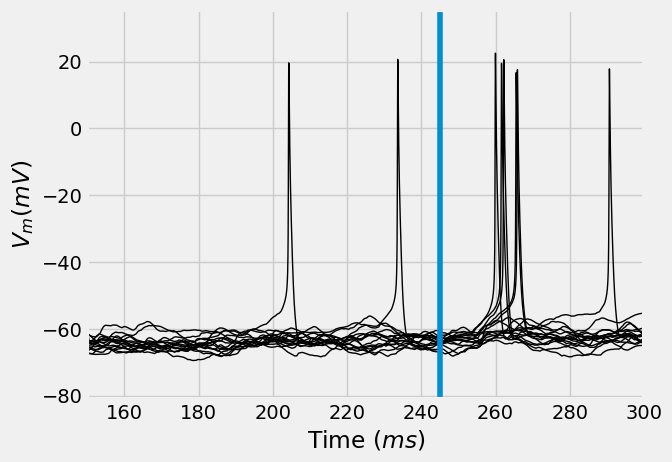

In [126]:
%matplotlib inline
I.plt.style.use("fivethirtyeight")

ax = vt.T.plot(legend=False, lw=1, c='k', xlabel="Time ($ms$)", ylabel="$V_m (mV)$")
ax.axvline(stim_onset, label=f"Stimulus onset = {stim_onset}")
ax.set_xlim((converge_t, 300))
I.plt.show()

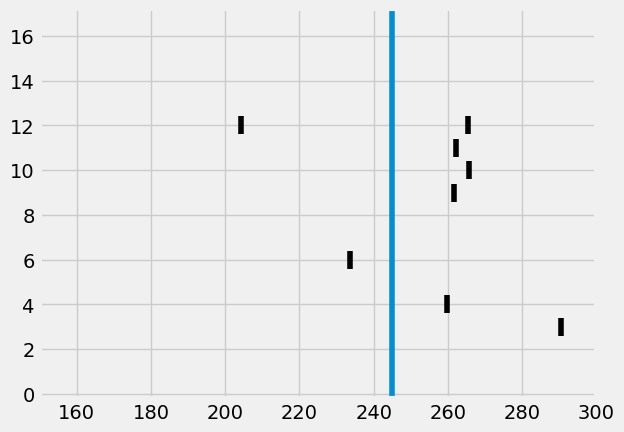

In [127]:
from visualize.rasterplot import rasterplot2

rasterplot2(st, c='k', y_plot_length=.8)
I.plt.axvline(stim_onset, label=f"Stimulus onset = {stim_onset}")
I.plt.xlim((converge_t, 300))
I.plt.show()

## Manipulations

Let us investigate how we can silence the input from $L6$ neurons, similar to [Egger et al. (2020)](https://www.cell.com/neuron/fulltext/S0896-6273(19)30884-0).
Let's start by investigating the [synapse activation dataframe](https://mpinb.github.io/in_silico_framework/file_formats.html#parsed-dataframe)

In [76]:
sa = db[f"stim_{second_surround_whisker}"]["synapse_activation"]

# All synapses activations of cell type L6cc for all simulation runs (see index)
sa[sa['synapse_type'].str.contains("L6cc")].compute()

,synapse_type,synapse_ID,soma_distance,section_ID,section_pt_ID,dendrite_label,0,1,2,3,4,5,6
sim_trial_index,,,,,,,,,,,,,
stim_C4/results/20250822-1542_seed2287520848_pid178653/000000,L6cc_A1,0,185.771836,90,117,Dendrite,63.940260,NaN,NaN,NaN,NaN,NaN,NaN
stim_C4/results/20250822-1542_seed2287520848_pid178653/000000,L6cc_A1,1,242.702257,155,235,Dendrite,273.149086,NaN,NaN,NaN,NaN,NaN,NaN
stim_C4/results/20250822-1542_seed2287520848_pid178653/000000,L6cc_A1,2,240.927344,10,186,ApicalDendrite,273.149086,NaN,NaN,NaN,NaN,NaN,NaN
stim_C4/results/20250822-1542_seed2287520848_pid178653/000000,L6cc_A1,6,530.380364,38,333,ApicalDendrite,50.843721,NaN,NaN,NaN,NaN,NaN,NaN
stim_C4/results/20250822-1542_seed2287520848_pid178653/000000,L6cc_A1,10,238.345563,155,227,Dendrite,180.606116,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
stim_C4/results/20250822-1542_seed3932428736_pid178570/000003,L6ccinv_E2,9,236.361331,104,33,Dendrite,218.238873,NaN,NaN,NaN,NaN,NaN,NaN
stim_C4/results/20250822-1542_seed3932428736_pid178570/000003,L6ccinv_E3,31,69.612081,4,50,Dendrite,147.964417,NaN,NaN,NaN,NaN,NaN,NaN
stim_C4/results/20250822-1542_seed3932428736_pid178570/000003,L6ccinv_Gamma,11,132.944682,165,44,Dendrite,221.128521,NaN,NaN,NaN,NaN,NaN,NaN


Using ISF, you can rerun the _exact_ same simulation with the _exact_ same synapses, or manipulate _exact_ synapse activations. This is the approach we will go for in this tutorial. Let us resimulate these simulation runs, but this time without input from the $L6cc$ population.

> Note: you could e.g. also adapt values in the [Network parameters](https://mpinb.github.io/in_silico_framework/file_formats.html#network-parameters) and run new simulations from these adapted parameter files using [simrun.run_new_simulations](../../api_reference/simrun/run_new_simulations/index.rst). 

In [ ]:
def silence_l6cc_subpopulation(sa, cell_type="L6cc", column=second_surround_whisker):
    """Remove all synapse activations from a SA dataframe if they are from L6cc neurons in 
    the barrel of the simulated whisker"""
    return sa[~sa['synapse_type'].str.contains(f"{cell_type}_{column}")]

In theory, we can also add synapse activations to the synapse activation dataframe, e.g. to achieve the aforemention upregulation. For the sake of keeping this tutorial brief, we will omit this idea, and keep the manipulation simple, albeit drastic.

In [79]:
if 'simrun_manipulations' in db.keys(): 
    del db['simrun_manipulations']
# Create new folder for results
db.create_managed_folder('simrun_manipulations')

ds = I.simrun_rerun_db(
    db = db[f'stim_{second_surround_whisker}'],
    outdir = db['simrun_manipulations'],
    synapse_activation_modify_functions = [silence_l6cc_subpopulation]  # <-------------- this is the crux of this manipulation
)

[WARNING] isf_data_base: ISF has uncommitted changes - reproducing results may not be possible.


In [80]:
from dask.distributed import wait
futures = client.compute(ds)
wait(futures) # block computation util results are in

DoneAndNotDoneFutures(done={<Future: finished, type: builtins.NoneType, key: _evoked_activity-a1c8eb78-a98b-4891-8363-a871d78415e2>, <Future: finished, type: builtins.NoneType, key: _evoked_activity-863c6be0-6a2e-47b6-9fff-3df02a59e8b3>, <Future: finished, type: builtins.NoneType, key: _evoked_activity-d062abdf-b628-4399-90f6-56be0592bd60>, <Future: finished, type: builtins.NoneType, key: _evoked_activity-f746b3f9-d299-4b3e-bf0e-bf1aa54d8c61>}, not_done=set())

In [ ]:
I.db_init_simrun_general.init(
    db.create_sub_db(f"stim_{second_surround_whisker}_manipulations"),
    db['simrun_manipulations'],
    client=client
)

In [90]:
vt_manipulations = db[f'stim_{second_surround_whisker}_manipulations']['voltage_traces']
vt_manipulations = client.compute(vt_manipulations).result()

In [91]:
st_manipulations = db[f"stim_{second_surround_whisker}_manipulations"]['spike_times']

(150.0, 300.0)

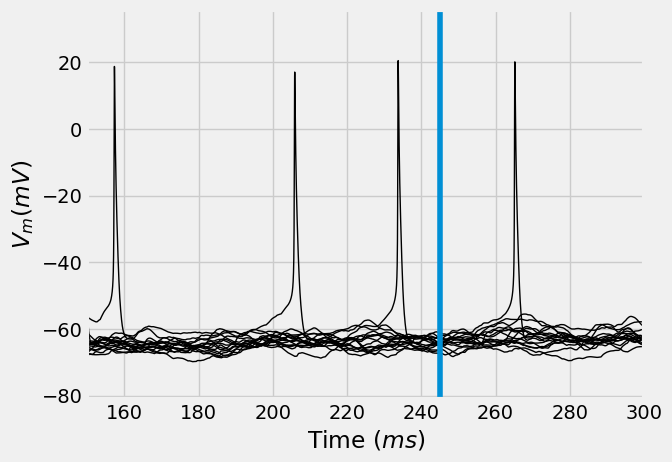

In [92]:
ax = vt_manipulations.T.plot(legend=False, lw=1, c='k', xlabel="Time ($ms$)", ylabel="$V_m (mV)$")
ax.axvline(stim_onset, label=f"Stimulus onset = {stim_onset}")
ax.set_xlim((converge_t, 300))

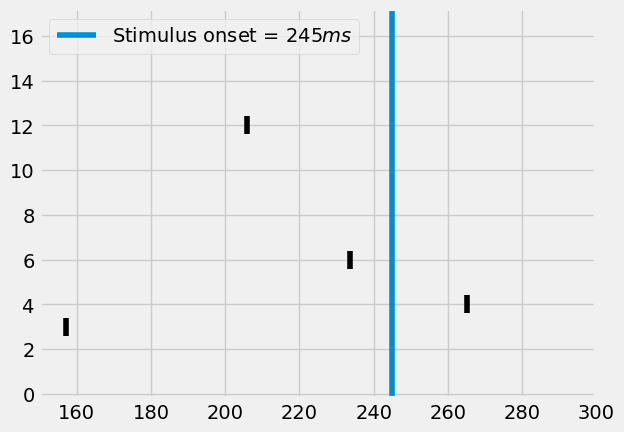

In [125]:
rasterplot2(st_manipulations, c='k', y_plot_length=.8)
I.plt.axvline(stim_onset, label=f"Stimulus onset = ${stim_onset}ms$")
I.plt.xlim((converge_t, 300))
I.plt.legend()
I.plt.show()

## Comparing the results

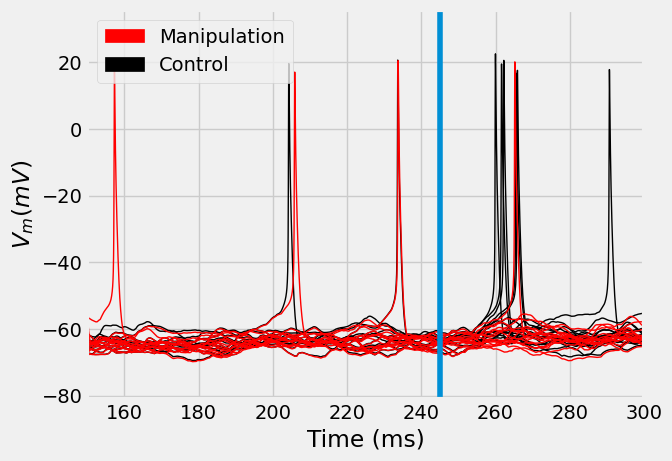

In [122]:
import matplotlib.patches as mpatches

ax = vt.T.plot(legend=False, label="Control", lw=1, c='k')
ax = vt_manipulations.T.plot(legend=False, label="Manipulation", ax=ax, lw=1, c='red')
patch_manip = mpatches.Patch(color='red', label='Manipulation')
patch_control = mpatches.Patch(color='k', label='Control')
I.plt.legend(handles=[patch_manip, patch_control])
I.plt.xlabel("Time (ms)")
I.plt.ylabel("$V_m (mV)$")
I.plt.xlim((converge_t, 300))
I.plt.axvline(stim_onset)
I.plt.show()

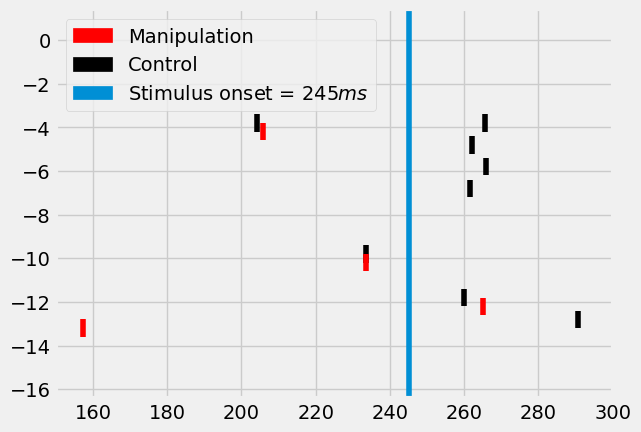

In [121]:
fig = I.plt.figure()
ax = fig.gca()

rasterplot2(st, c='k', y_plot_length=.8, ax=ax, y_offset=.2)
rasterplot2(st_manipulations, c='red', y_plot_length=.8, ax=ax, y_offset=-.2)
I.plt.axvline(stim_onset, label="Simulus onset")

patch_manip = mpatches.Patch(color='red', label='Manipulation')
patch_control = mpatches.Patch(color='k', label='Control')
patch_onset = mpatches.Patch(
    color=I.plt.rcParams['axes.prop_cycle'].by_key()['color'][0], 
    label='Stimulus onset = ${}ms$'.format(stim_onset))
I.plt.xlim((converge_t, 300))
I.plt.legend(handles=[patch_manip, patch_control, patch_onset])
I.plt.show()

## Interpreting the result

We have now simulated a $L5tt$ neuron in the $C2$ column of the barrel cortex.
We showed how to use ISF to re-run these existing simulations, while providing targeted manipulations at the single synapse level. 
In this case, the manipulation consisted of silencing all synapses that originate from any $L6cc$ population. 
This completely eradicated the responses of these neurons to whisker stimuli that are $2nd$ surround to the $C2$ column. It also eradicated spontaneous ongoing activity before the stimulus.

Of course, completely silencing an input neuron population naturally reduces response probability, especially if the lost synaptic input is not compensated for. The purpose of this tutorial is not to provide a full-fledged investigation on the effect of $L6cc$ input to $L5tt$ neurons. For that, you can refer to [Egger et al. (2020)](https://www.cell.com/neuron/fulltext/S0896-6273(19)30884-0). The purpose of this tutorial is to show how to use ISF API to perform such manipulations.